    period  confidence  consumption  investment      output  unemployment
0        0         1.0     0.000000         0.0  100.000000      0.050000
1        1         1.0    87.000000        25.6  132.600000      0.050000
2        2         1.0   108.190000        25.6  153.790000      0.050000
3        3         1.0   121.963500        25.6  167.563500      0.050000
4        4         1.0   130.916275        25.6  176.516275      0.050000
5        5         1.0   136.735579        25.6  182.335579      0.050000
6        6         1.0   140.518126        25.6  186.118126      0.050000
7        7         1.0   142.976782        25.6  188.576782      0.050000
8        8         1.0   144.574908        25.6  190.174908      0.050000
9        9         1.0   145.613690        25.6  191.213690      0.050000
10      10        -1.5   126.288899         0.6  146.888899      0.050000
11      11        -1.5    97.477784         0.6  118.077784      0.050000
12      12        -1.5    78.750560   

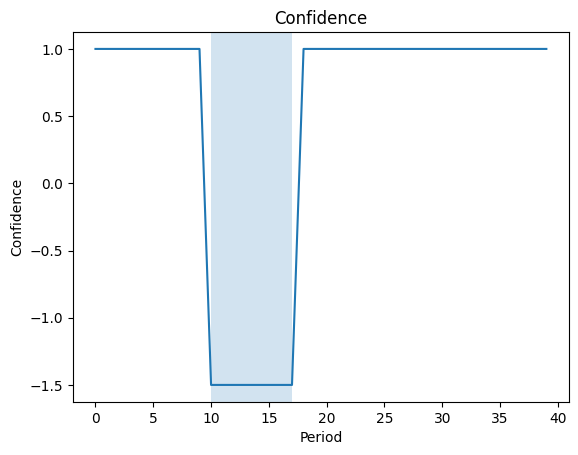

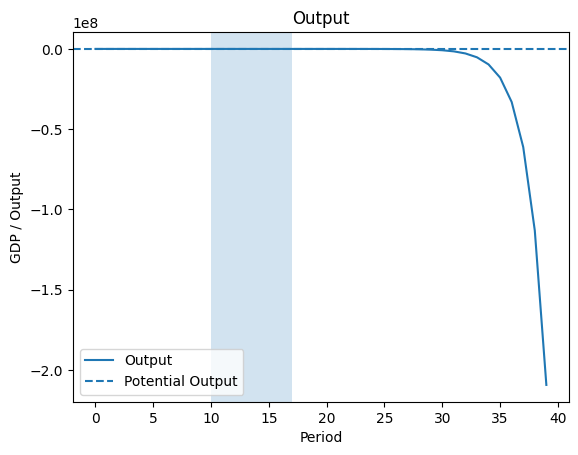

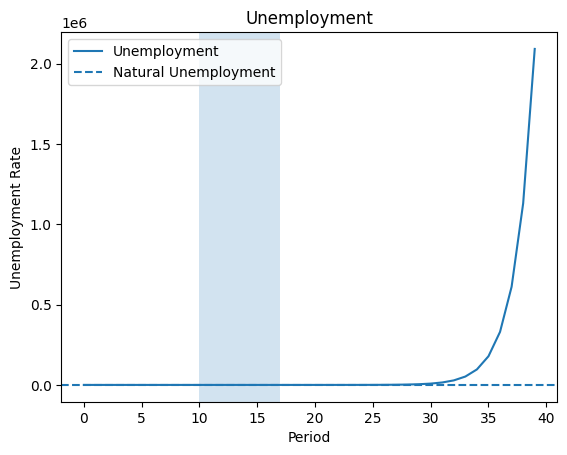

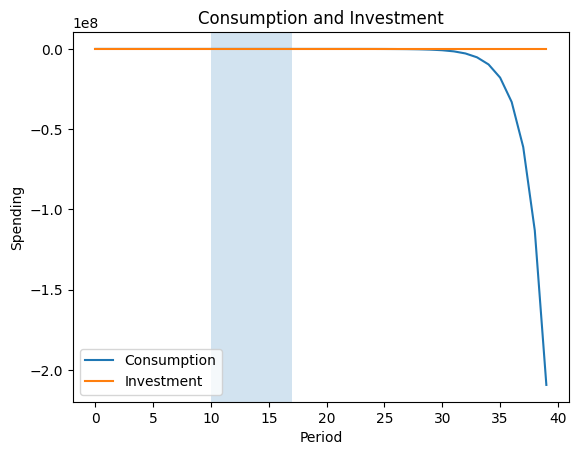

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#1. parameters

# Number of periods to simulate
T = 40

# Consumption equation parameters
a = 20.0    # autonomous consumption
b = 0.65    # marginal propensity to consume out of past income
c = 120.0   # how strongly unemployment reduces consumption
cons_confidence_sensitivity = 8.0  # effect of confidence on consumption

# Investment equation parameters
i0 = 18.0   # baseline investment
ir = 80.0   # how strongly interest rates reduce investment
ic = 10.0   # how strongly confidence increases investment

# Government spending and interest rate
G = 20.0
r_normal = 0.03  # 3% interest rate

# Potential output and natural unemployment
Y_potential = 100.0
U_natural = 0.05
alpha = 0.01  # how strongly unemployment rises when output falls below potential

# Shock timing
shock_start = 10
shock_end = 18

# Confidence levels
confidence_normal = 1.0
confidence_recession = -1.5

# 2. initial arrays

t = np.arange(T)

confidence = np.full(T, confidence_normal)
r = np.full(T, r_normal)

C = np.zeros(T)   # consumption
I = np.zeros(T)   # investment
Y = np.zeros(T)   # output
U = np.zeros(T)   # unemployment

# Initial conditions
Y[0] = Y_potential
U[0] = U_natural

# 3. confidence shock

confidence[shock_start:shock_end] = confidence_recession

# 4.Simulation loop

for period in range(1, T):
    # Consumption equation
    C[period] = (
        a
        + b * Y[period - 1]
        - c * U[period - 1]
        + cons_confidence_sensitivity * confidence[period]
    )

    # Investment equation
    I[period] = (
        i0
        - ir * r[period]
        + ic * confidence[period]
    )

    # Keynesian output identity
    Y[period] = C[period] + I[period] + G

    # Unemployment rises if output is below potential
    output_gap = max(0.0, Y_potential - Y[period])
    U[period] = U_natural + alpha * output_gap


# 5. DF with the results


results = pd.DataFrame({
    "period": t,
    "confidence": confidence,
    "consumption": C,
    "investment": I,
    "output": Y,
    "unemployment": U
})

print(results.head(15))

# 6.Results

plt.figure()
plt.plot(t, confidence)
plt.axvspan(shock_start, shock_end - 1, alpha=0.2)
plt.title("Confidence")
plt.xlabel("Period")
plt.ylabel("Confidence")
plt.show()

plt.figure()
plt.plot(t, Y, label="Output")
plt.axhline(Y_potential, linestyle="--", label="Potential Output")
plt.axvspan(shock_start, shock_end - 1, alpha=0.2)
plt.title("Output")
plt.xlabel("Period")
plt.ylabel("GDP / Output")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, U, label="Unemployment")
plt.axhline(U_natural, linestyle="--", label="Natural Unemployment")
plt.axvspan(shock_start, shock_end - 1, alpha=0.2)
plt.title("Unemployment")
plt.xlabel("Period")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, C, label="Consumption")
plt.plot(t, I, label="Investment")
plt.axvspan(shock_start, shock_end - 1, alpha=0.2)
plt.title("Consumption and Investment")
plt.xlabel("Period")
plt.ylabel("Spending")
plt.legend()
plt.show()